# DRN waveform spatial organization — cleaned analysis

This notebook reorganizes `F_waveform_space_DRN.ipynb` around one canonical `(session, unit)` table.

**Main questions**
1. Do individual waveform features vary systematically with CCF position?
2. What do those spatially varying features correspond to in waveform shape?
3. Do multivariate waveform combinations (PCA / CCA) covary with anatomy?

**Robustness changes**
- all merges are explicit on `session + unit`;
- invalid waveform normalizations become `NaN` instead of `inf`;
- spatial tests use feature-specific finite rows;
- PCA/CCA reject non-finite and zero-variance inputs;
- DR mesh handling is separated from unit-coordinate conversion;
- plotting and statistics use the same canonical analysis population.

The original notebook is left unchanged as an archive.

## 1. Imports and configuration

In [15]:
import sys
import os
import json
import pickle
from pathlib import Path

sys.path.append('/root/capsule/code/beh_ephys_analysis')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize

from scipy.stats import zscore, rankdata
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from statsmodels.stats.multitest import multipletests
from trimesh import load_mesh

from utils.ccf_utils import project_to_plane
from utils.combine_tools import apply_qc, spatial_dependence_summary
from utils.capsule_migration import capsule_directories

capsule_dirs = capsule_directories()
%matplotlib inline


In [16]:
# -----------------------------
# Analysis configuration
# -----------------------------
criteria_name = 'waveform_low_DRN'
waveform_version = '_raw'
ISI_MAX = 0.5
RANDOM_SEED = 42
N_PERM = 2000
K_NEIGHBORS = 30
N_SPLITS = 5

UNIT_KEY = ['session', 'unit']
CCF_COLS = ['x_ccf', 'y_ccf', 'z_ccf']

mesh_file = '/root/capsule/data/ccf_meshes/DR_bregma_lps_mm.obj'
target_folder = os.path.join(capsule_dirs['manuscript_fig_dir'], 'F_waveform_space_DRN_v2')
os.makedirs(target_folder, exist_ok=True)

# Unit x/y/z coordinates are stored in the older absolute LPS-mm convention.
# Subtract this origin to express them relative to bregma.
# IMPORTANT: DR_bregma_lps_mm.obj is already bregma-relative LPS mm and does NOT use this subtraction.
BREGMA_LPS_MM = np.array([-5.74, 5.4, -0.45])
MIRROR_ML = True

focus_features = [
    'post_w',
    'trough_post_ratio_1D',
    'post_trough_slope',
    'pre_slope',
    'symmetry_slope_div_log',
    'symmetry_trough_dis',
    'symmetry_inte_div_log',
]


## 2. Numerical safety helpers

In [17]:
def safe_divide(num, den, eps=1e-10):
    """Elementwise division; undefined/near-zero denominators become NaN."""
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    out = np.full(np.broadcast_shapes(num.shape, den.shape), np.nan, dtype=float)
    valid = np.isfinite(num) & np.isfinite(den) & (np.abs(den) > eps)
    np.divide(num, den, out=out, where=valid)
    return out


def safe_unit_vectors(v, axis=0, eps=1e-12):
    """Normalize vectors without divide-by-zero warnings."""
    v = np.asarray(v, dtype=float)
    norm = np.linalg.norm(v, axis=axis, keepdims=True)
    return np.divide(v, norm, out=np.full_like(v, np.nan), where=norm > eps)


def finite_rows(df, cols):
    arr = df[cols].to_numpy(dtype=float)
    return np.isfinite(arr).all(axis=1)


def assert_unique_units(df, name):
    dup = df.duplicated(UNIT_KEY, keep=False)
    if dup.any():
        display(df.loc[dup, UNIT_KEY].sort_values(UNIT_KEY))
        raise ValueError(f'{name} has duplicate (session, unit) keys')


def ccf_to_bregma_relative(df):
    ccf = df[CCF_COLS].to_numpy(dtype=float).copy()
    ccf -= BREGMA_LPS_MM
    if MIRROR_ML:
        ccf[:, 0] = np.abs(ccf[:, 0])
    return ccf


## 3. Load unit table, apply QC, and load waveform features

In [18]:
combined_unit_file = os.path.join(
    capsule_dirs['manuscript_fig_prep_dir'], 'combined_unit_tbl', 'combined_unit_tbl.pkl'
)
criteria_file = os.path.join(
    '/root/capsule/code/beh_ephys_analysis/session_combine/metrics', f'{criteria_name}.json'
)
wf_file = os.path.join(
    capsule_dirs['manuscript_fig_prep_dir'], 'waveforms_np', 'combined_features.csv'
)

with open(combined_unit_file, 'rb') as f:
    combined_tagged_units = pickle.load(f)
with open(criteria_file, 'r') as f:
    constraints = json.load(f)

combined_tagged_units_filtered, combined_tagged_units, fig, axes = apply_qc(
    combined_tagged_units, constraints
)
fig.savefig(os.path.join(target_folder, 'quality_metrics.pdf'), bbox_inches='tight')
plt.close(fig)

wf_features = pd.read_csv(wf_file)
wf_features = wf_features[[c for c in wf_features.columns if not c.startswith('wf_pc')]]

assert_unique_units(combined_tagged_units_filtered, 'combined_tagged_units_filtered')
assert_unique_units(wf_features, 'wf_features')

print('QC-tagged units:', len(combined_tagged_units_filtered))
print('Waveform-feature units:', len(wf_features))


Applying bounds for isi_violations: [0.0, 0.1]
 - isi_violations: 951 -> 561 units passed
Applying items for qc_pass: [True]
 - qc_pass: 561 -> 469 units passed
Applying bounds for peak: [-1000, -0.1]
 - peak: 469 -> 430 units passed
Applying items for probe: [2]
 - probe: 430 -> 430 units passed
Applying opto conditions: ['p_max', 'eu', 'corr', 'tag_loc', 'lat_max_p', 'p_mean', 'sig_counts']
Number of opto rows after filtering: 207
Number of non-opto rows after filtering: 430
QC-tagged units: 207
Waveform-feature units: 189


## 4. Normalize raw waveforms safely and attach them by unit key

In [19]:
wf_col = f'wf{waveform_version}'
if wf_col not in combined_tagged_units_filtered.columns:
    raise KeyError(f'Missing waveform column: {wf_col}')

all_wfs = np.stack(combined_tagged_units_filtered[wf_col].to_numpy())
baseline = np.nanmean(all_wfs[:, :3], axis=1)
denom = all_wfs[:, 30] - baseline

valid_norm = np.isfinite(denom) & (np.abs(denom) > 1e-10)
all_wfs_nl = np.full_like(all_wfs, np.nan, dtype=float)
all_wfs_nl[valid_norm] = (
    all_wfs[valid_norm] - baseline[valid_norm, None]
) / denom[valid_norm, None]

# Preserve the old bad-waveform criterion, but do it safely.
raw_denom = all_wfs[:, 30]
all_wfs_nl_raw = safe_divide(all_wfs, raw_denom[:, None])
bad_shape = np.isfinite(all_wfs_nl_raw[:, 0]) & (all_wfs_nl_raw[:, 0] > 1)
all_wfs_nl[bad_shape] = np.nan

waveform_lookup = combined_tagged_units_filtered[UNIT_KEY].copy()
waveform_lookup['wf_nl'] = list(all_wfs_nl)
waveform_lookup['wf_norm_valid'] = np.isfinite(all_wfs_nl).all(axis=1)

print(f'Waveforms total: {len(all_wfs_nl)}')
print(f'Valid normalization denominator: {valid_norm.sum()}')
print(f'Flagged by old bad-shape rule: {bad_shape.sum()}')
print(f'Fully finite normalized waveforms: {waveform_lookup.wf_norm_valid.sum()}')


Waveforms total: 207
Valid normalization denominator: 189
Flagged by old bad-shape rule: 1
Fully finite normalized waveforms: 188


## 5. Build the canonical analysis table

In [20]:
spatial_cols = UNIT_KEY + CCF_COLS + ['isi_violations']

analysis_df = wf_features.merge(
    combined_tagged_units_filtered[spatial_cols],
    on=UNIT_KEY,
    how='inner',
    validate='one_to_one',
).merge(
    waveform_lookup,
    on=UNIT_KEY,
    how='left',
    validate='one_to_one',
)

# Convert any pre-existing +/- infinity to missing data explicitly.
numeric_cols = analysis_df.select_dtypes(include=np.number).columns
n_inf = np.isinf(analysis_df[numeric_cols].to_numpy()).sum()
if n_inf:
    print(f'Replacing {n_inf} infinite numeric values with NaN')
    analysis_df[numeric_cols] = analysis_df[numeric_cols].replace([np.inf, -np.inf], np.nan)

base_mask = (
    analysis_df['isi_violations'].lt(ISI_MAX)
    & finite_rows(analysis_df, CCF_COLS)
)
base_df = analysis_df.loc[base_mask].copy().reset_index(drop=True)
base_df['ccf_plot'] = list(ccf_to_bregma_relative(base_df))

assert_unique_units(base_df, 'base_df')

print('Merged analysis units:', len(analysis_df))
print('Base spatial-analysis units:', len(base_df))
print('Unique sessions:', base_df.session.nunique())
print('Finite normalized waveforms:', base_df.wf_norm_valid.sum())
print()
print('Missing focus features:')
print(base_df[focus_features].isna().sum().sort_values(ascending=False))


Merged analysis units: 189
Base spatial-analysis units: 189
Unique sessions: 37
Finite normalized waveforms: 188

Missing focus features:
post_w                    4
trough_post_ratio_1D      4
post_trough_slope         4
pre_slope                 4
symmetry_slope_div_log    4
symmetry_trough_dis       4
symmetry_inte_div_log     4
dtype: int64


## 6. Waveform PCA — fit only valid waveforms, merge scores back by key

In [21]:
pca_wave_mask = base_df['wf_norm_valid'].to_numpy()
waveforms_for_pca = np.stack(base_df.loc[pca_wave_mask, 'wf_nl'].to_numpy())

if len(waveforms_for_pca) < 3:
    raise ValueError('Too few valid waveforms for PCA')

waveform_pca = PCA(n_components=3)
pca_scores = waveform_pca.fit_transform(waveforms_for_pca)

pca_score_df = base_df.loc[pca_wave_mask, UNIT_KEY].copy()
for i in range(3):
    pca_score_df[f'wf_pc_{i+1}'] = pca_scores[:, i]

base_df = base_df.merge(pca_score_df, on=UNIT_KEY, how='left', validate='one_to_one')

print('PCA units:', len(pca_score_df))
print('Explained variance ratio:', waveform_pca.explained_variance_ratio_)


PCA units: 188
Explained variance ratio: [0.74315388 0.08898129 0.07581927]


## 6.5 Grid visualization of all individual waveforms

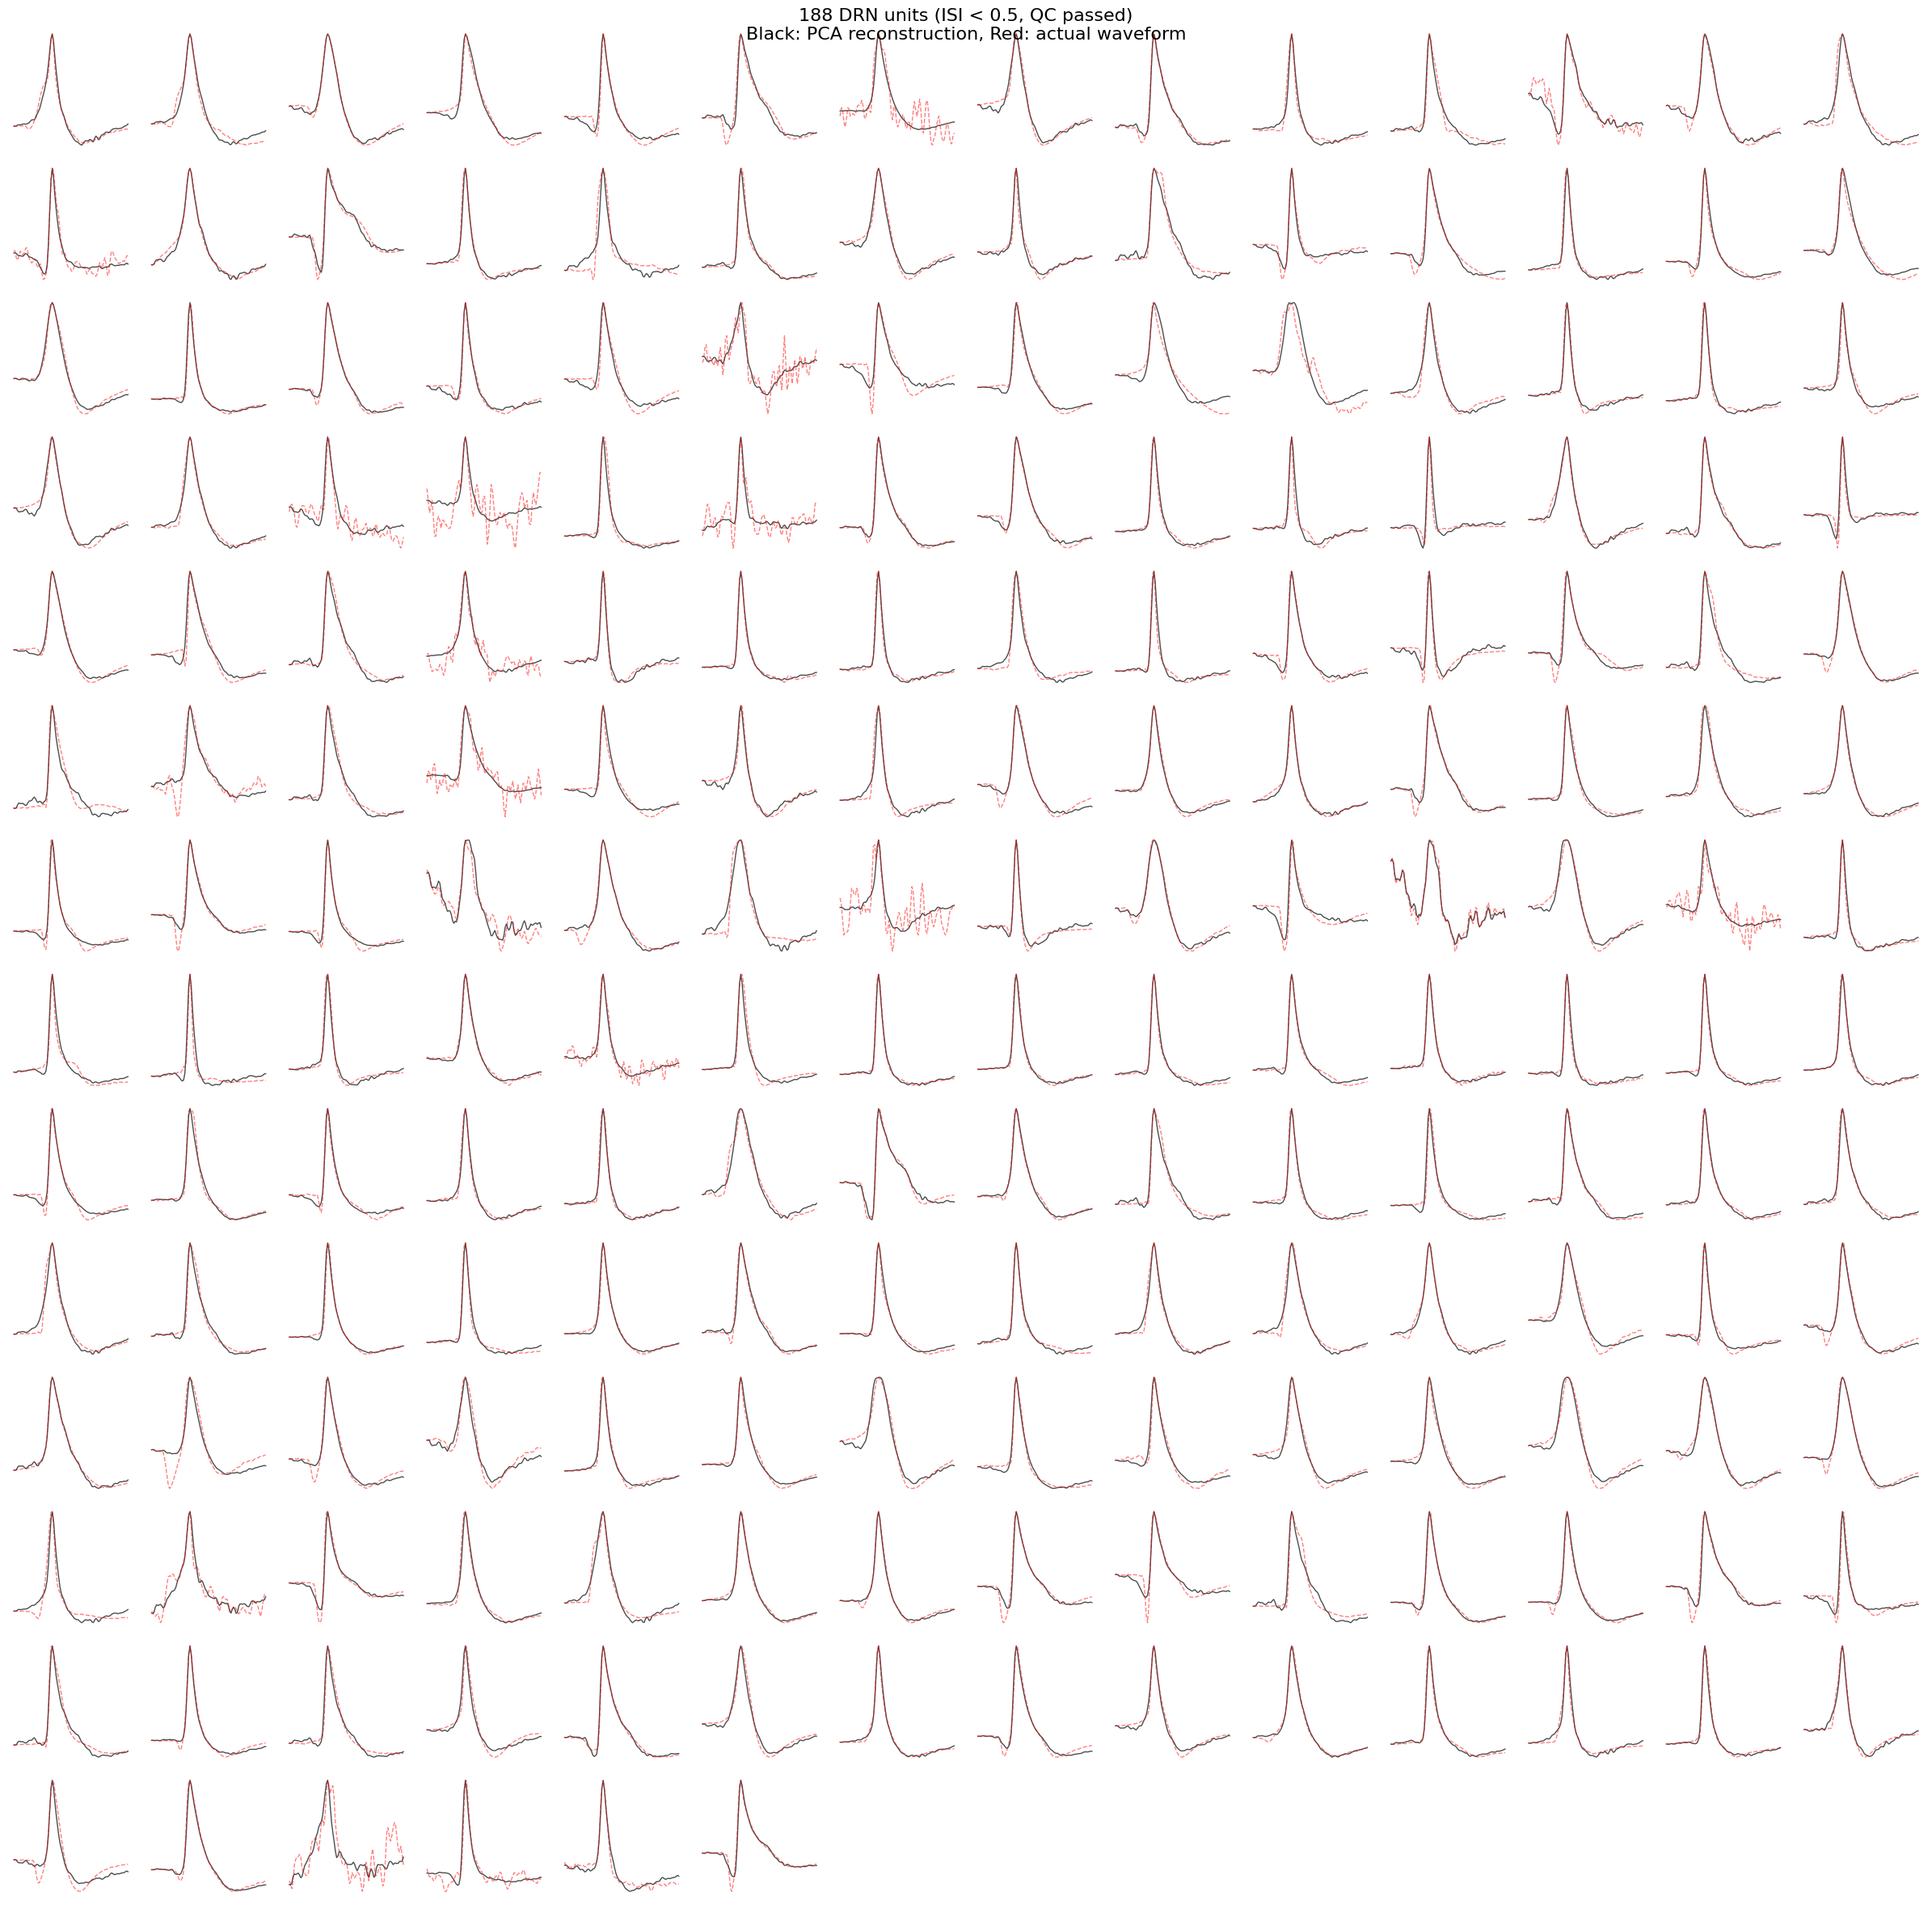

Grid plot: 188 waveforms (14×14 grid)
PCA explains 90.8% of variance with 3 components


In [22]:
# Extract clean waveforms (valid normalized waveforms)
all_wfs_nl_clean = np.stack(base_df.loc[base_df['wf_norm_valid'], 'wf_nl'].to_numpy())
pc_time = (np.arange(all_wfs_nl_clean.shape[1]) - 30) / 30000 * 1000  # ms

# Also get PCA-reconstructed waveforms for comparison
all_wfs_pc = waveform_pca.inverse_transform(pca_scores)

# Create grid figure
n_units = len(all_wfs_nl_clean)
grid_size = int(np.ceil(np.sqrt(n_units)))

fig = plt.figure(figsize=(24, 24))
gs = gridspec.GridSpec(grid_size, grid_size, figure=fig)

for i in range(n_units):
    ax = fig.add_subplot(gs[i])
    # Plot PCA reconstruction (black) and actual waveform (red)
    ax.plot(pc_time, all_wfs_pc[i], alpha=0.7, color='k', linewidth=1)
    ax.plot(pc_time, all_wfs_nl_clean[i], color='r', alpha=0.5, linestyle='--', linewidth=1)
    
    # Minimal axes for compact display
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

title = f"{n_units} DRN units (ISI < {ISI_MAX}, QC passed)\nBlack: PCA reconstruction, Red: actual waveform"
plt.suptitle(title, fontsize=16)
plt.tight_layout()
fig.savefig(os.path.join(target_folder, f'All_waveforms_grid_{criteria_name}.pdf'), dpi=150)
plt.show()

print(f'Grid plot: {n_units} waveforms ({grid_size}×{grid_size} grid)')
print(f'PCA explains {waveform_pca.explained_variance_ratio_[:3].sum():.1%} of variance with 3 components')

## 7. Load DR mesh and define plotting geometry

In [23]:
ml, ap, dv = 0, 1, 2
planes = {
    'sag': [ap, dv],
    'hor': [ml, ap],
    'cor': [ml, dv],
}
axis_names = {
    ml: '|ML| from midline (mm)' if MIRROR_ML else 'ML from bregma (mm)',
    ap: 'AP from bregma (mm)',
    dv: 'DV from bregma (mm)',
}

mesh = load_mesh(mesh_file)
mesh_vertices_mm = np.asarray(mesh.vertices, dtype=float).copy()
# DR_bregma_lps_mm.obj is already bregma-relative LPS in mm.
if MIRROR_ML:
    mesh_vertices_mm[:, ml] = np.abs(mesh_vertices_mm[:, ml])

mesh_contours = {
    name: project_to_plane(mesh_vertices_mm, axes, pitch=0.02, margin=0.5)
    for name, axes in planes.items()
}

ccfs_all = np.stack(base_df['ccf_plot'].to_numpy())
plot_margin = 0.30
plot_limits = {}
for name, axes_ in planes.items():
    xdim, ydim = axes_
    xs = np.concatenate([ccfs_all[:, xdim], mesh_vertices_mm[:, xdim]])
    ys = np.concatenate([ccfs_all[:, ydim], mesh_vertices_mm[:, ydim]])
    plot_limits[name] = {
        'xlim': (np.nanmin(xs)-plot_margin, np.nanmax(xs)+plot_margin),
        'ylim': (np.nanmin(ys)-plot_margin, np.nanmax(ys)+plot_margin),
    }

print('Mesh ranges (ML/AP/DV):')
for i, name in enumerate(['ML','AP','DV']):
    print(name, np.nanmin(mesh_vertices_mm[:,i]), np.nanmax(mesh_vertices_mm[:,i]))
print('Unit ranges (ML/AP/DV):')
for i, name in enumerate(['ML','AP','DV']):
    print(name, np.nanmin(ccfs_all[:,i]), np.nanmax(ccfs_all[:,i]))


Mesh ranges (ML/AP/DV):
ML 0.0 0.1625
AP 3.9875 4.9625
DV -4.1875 -2.7625
Unit ranges (ML/AP/DV):
ML 0.0008828073517861412 0.571435928174485
AP 3.7577186206863704 4.908042919223204
DV -4.872704467941764 -2.8339777905491337


## 8. Individual waveform-feature spatial dependence

In [24]:
spatial_dependence_results = {}

numeric_feature_cols = [
    c for c in wf_features.columns
    if c not in UNIT_KEY and np.issubdtype(wf_features[c].dtype, np.number)
]

for feature in numeric_feature_cols:
    feature_mask = np.isfinite(base_df[feature].to_numpy(dtype=float))
    df_f = base_df.loc[feature_mask]
    if len(df_f) <= K_NEIGHBORS:
        print(f'Skip {feature}: only {len(df_f)} finite units')
        continue

    coords = np.stack(df_f['ccf_plot'].to_numpy())
    values = df_f[feature].to_numpy(dtype=float)

    if np.nanstd(values) <= 1e-12:
        print(f'Skip {feature}: zero/near-zero variance')
        continue

    spatial_dependence_results[feature] = spatial_dependence_summary(
        coords,
        values,
        k_neighbors=K_NEIGHBORS,
        n_splits=N_SPLITS,
        permutations=N_PERM,
        seed=RANDOM_SEED,
    )

# FDR corrections, separately for KNN and linear trend.
features_tested = list(spatial_dependence_results)
if features_tested:
    p_knn = [spatial_dependence_results[f]['cv_predictability_knn']['p_value_permutation'] for f in features_tested]
    rej, padj, _, _ = multipletests(p_knn, alpha=0.05, method='fdr_bh')
    for f, r, p in zip(features_tested, rej, padj):
        spatial_dependence_results[f]['cv_predictability_knn']['p_value_permutation_fdr'] = p
        spatial_dependence_results[f]['cv_predictability_knn']['significant_fdr'] = bool(r)

    p_lr = [spatial_dependence_results[f]['linear_trend']['p_value_permutation_r2'] for f in features_tested]
    rej, padj, _, _ = multipletests(p_lr, alpha=0.05, method='fdr_bh')
    for f, r, p in zip(features_tested, rej, padj):
        spatial_dependence_results[f]['linear_trend']['p_value_permutation_r2_fdr'] = p
        spatial_dependence_results[f]['linear_trend']['significant_fdr'] = bool(r)

results_file = os.path.join(target_folder, f'spatial_dependence_results_{criteria_name}.pkl')
with open(results_file, 'wb') as f:
    pickle.dump(spatial_dependence_results, f)

print('Features tested:', len(spatial_dependence_results))


Skip probe: zero/near-zero variance
Features tested: 29


## 9. Main DRN feature-in-space figure

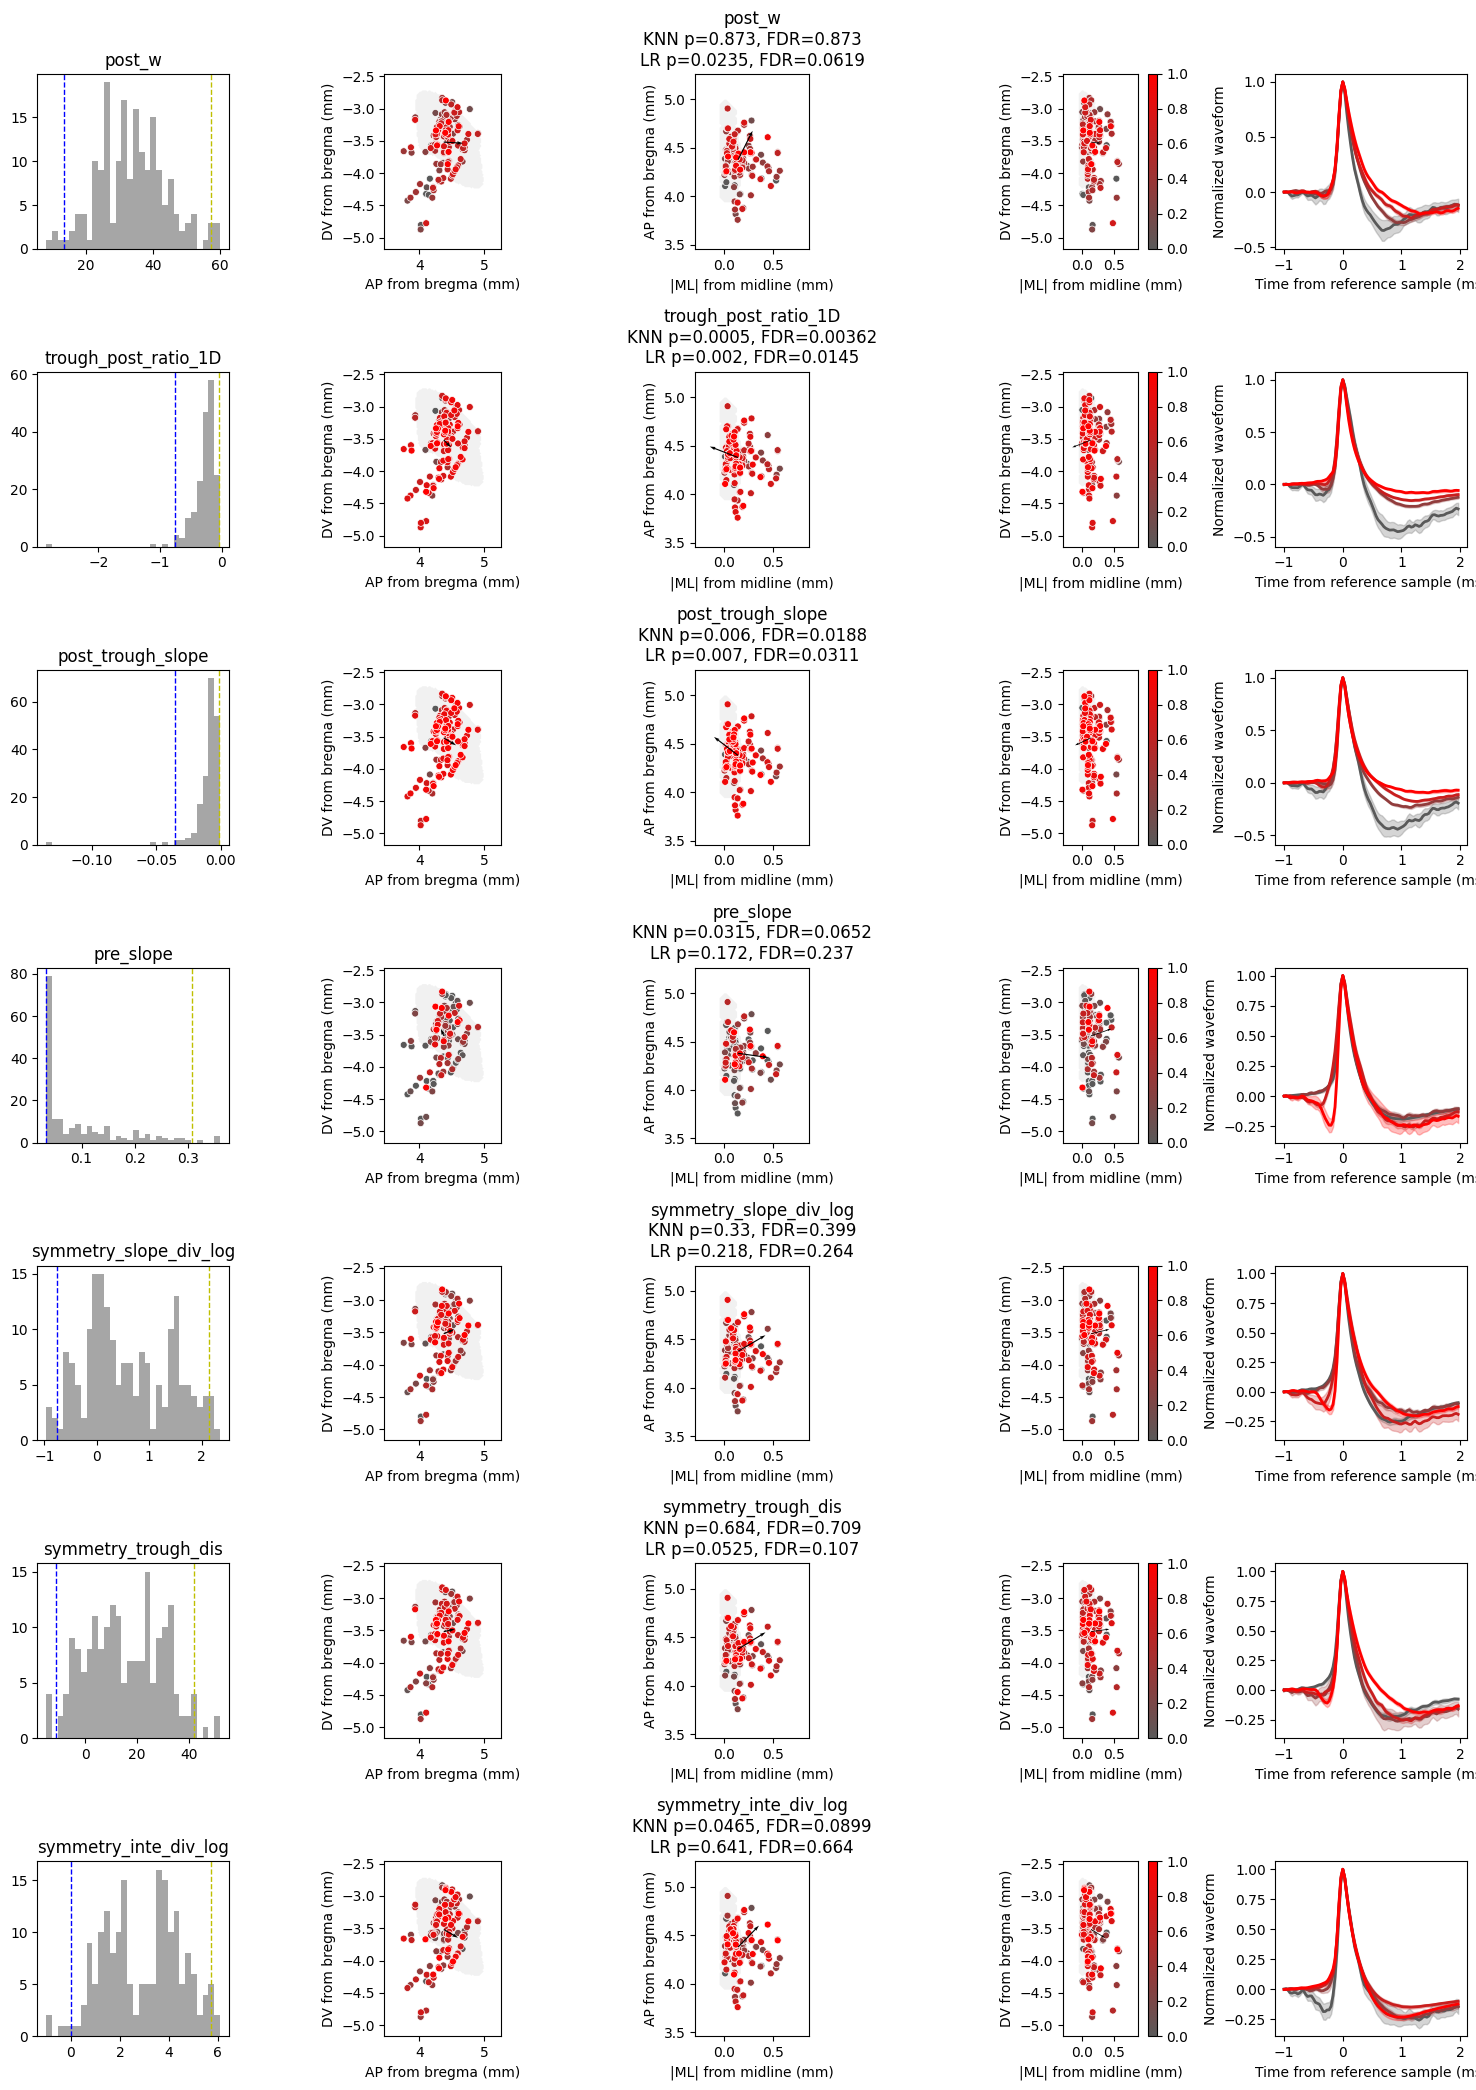

In [10]:
cmap = LinearSegmentedColormap.from_list(
    'gray_red', [(0, (0.35, 0.35, 0.35)), (1, (1, 0, 0))]
)
bin_num = 4

fig, axes = plt.subplots(len(focus_features), 5, figsize=(15, 3*len(focus_features)), squeeze=False)

for row, feature in enumerate(focus_features):
    if feature not in spatial_dependence_results:
        axes[row, 0].text(0.5, 0.5, f'{feature} not tested', ha='center', va='center')
        for ax in axes[row]: ax.axis('off')
        continue

    # Feature-specific population: finite feature + valid CCF.
    df_f = base_df.loc[np.isfinite(base_df[feature].to_numpy(dtype=float))].copy()
    values = df_f[feature].to_numpy(dtype=float)
    ccfs = np.stack(df_f['ccf_plot'].to_numpy())

    # Histogram / clipping thresholds.
    ax = axes[row, 0]
    ax.hist(values, bins=30, color='gray', alpha=0.7)
    low, high = np.nanquantile(values, [0.02, 0.98])
    ax.axvline(low, color='blue', linestyle='--', linewidth=1)
    ax.axvline(high, color='y', linestyle='--', linewidth=1)
    ax.set_title(feature)

    if not np.isfinite(high-low) or (high-low) <= 1e-12:
        color_values = np.full(len(values), 0.5)
    else:
        color_values = (np.clip(values, low, high) - low) / (high-low)
    sort_ind = np.argsort(color_values)

    # Mean waveforms by feature quantile: only units with valid waveforms.
    ax_wf = axes[row, 4]
    wf_mask = df_f['wf_norm_valid'].to_numpy()
    wf_values = values[wf_mask]
    wf_arrays = df_f.loc[wf_mask, 'wf_nl'].to_numpy()
    if len(wf_values) >= bin_num and np.unique(wf_values).size >= bin_num:
        edges = np.nanquantile(wf_values, np.linspace(0, 1, bin_num+1))
        for b in range(bin_num):
            bm = ((wf_values >= edges[b]) &
                  (wf_values <= edges[b+1] if b == bin_num-1 else wf_values < edges[b+1]))
            if not bm.any():
                continue
            wfs = np.stack(wf_arrays[bm])
            mean_wf = np.nanmean(wfs, axis=0)
            n_eff = np.sum(np.isfinite(wfs), axis=0)
            sem = safe_divide(np.nanstd(wfs, axis=0), np.sqrt(n_eff))
            t = (np.arange(wfs.shape[1]) - 30) / 30000 * 1000
            ax_wf.plot(t, mean_wf, color=cmap(b/(bin_num-1)), linewidth=2)
            ax_wf.fill_between(t, mean_wf-sem, mean_wf+sem, color=cmap(b/(bin_num-1)), alpha=0.25)
    ax_wf.set_xlabel('Time from reference sample (ms)')
    ax_wf.set_ylabel('Normalized waveform')

    result = spatial_dependence_results[feature]
    coef = np.asarray(result['linear_trend']['coef_const_x_y_z'], dtype=float)
    arrow_vec = safe_unit_vectors(np.array([coef[1], coef[2], coef[3]]), axis=0)
    arrow_start = np.nanmean(ccfs, axis=0)

    for plane, ax in zip(planes, axes[row, 1:4]):
        pa = planes[plane]
        for contour in mesh_contours[plane]:
            ax.fill(contour[:,0], contour[:,1], color='lightgray', alpha=0.3, linewidth=0, zorder=0)
        sc = ax.scatter(
            ccfs[sort_ind, pa[0]], ccfs[sort_ind, pa[1]],
            c=color_values[sort_ind], cmap=cmap, s=25,
            edgecolor='white', linewidth=0.5, zorder=2
        )
        if np.isfinite(arrow_vec).all():
            ax.quiver(
                arrow_start[pa[0]], arrow_start[pa[1]],
                arrow_vec[pa[0]], arrow_vec[pa[1]],
                angles='xy', scale_units='xy', scale=3, color='k', width=0.01, zorder=3
            )
        if plane == 'hor':
            knn_p = result['cv_predictability_knn']['p_value_permutation']
            lr_p = result['linear_trend']['p_value_permutation_r2']
            knn_fdr = result['cv_predictability_knn'].get('p_value_permutation_fdr', np.nan)
            lr_fdr = result['linear_trend'].get('p_value_permutation_r2_fdr', np.nan)
            ax.set_title(f'{feature}\nKNN p={knn_p:.3g}, FDR={knn_fdr:.3g}\nLR p={lr_p:.3g}, FDR={lr_fdr:.3g}')
        ax.set_xlabel(axis_names[pa[0]])
        ax.set_ylabel(axis_names[pa[1]])
        ax.set_aspect('equal')
        ax.set_xlim(plot_limits[plane]['xlim'])
        ax.set_ylim(plot_limits[plane]['ylim'])
        if plane == 'cor':
            fig.colorbar(sc, ax=ax, fraction=0.05)

plt.tight_layout()
fig.savefig(os.path.join(target_folder, f'wf_feature_in_space_{criteria_name}.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(target_folder, f'wf_feature_in_space_{criteria_name}.png'), dpi=300, bbox_inches='tight')
plt.show()


## 10. PCA components in space

In [25]:
spatial_dependence_results_pca = {}
for pc in ['wf_pc_1', 'wf_pc_2', 'wf_pc_3']:
    mask = np.isfinite(base_df[pc].to_numpy(dtype=float))
    df_pc = base_df.loc[mask]
    coords = np.stack(df_pc['ccf_plot'].to_numpy())
    vals = df_pc[pc].to_numpy(dtype=float)
    if len(vals) > K_NEIGHBORS and np.nanstd(vals) > 1e-12:
        spatial_dependence_results_pca[pc] = spatial_dependence_summary(
            coords, vals, k_neighbors=K_NEIGHBORS, n_splits=N_SPLITS,
            permutations=N_PERM, seed=RANDOM_SEED
        )

for pc, res in spatial_dependence_results_pca.items():
    print(pc,
          'KNN p=', res['cv_predictability_knn']['p_value_permutation'],
          'LR p=', res['linear_trend']['p_value_permutation_r2'])


wf_pc_1 KNN p= 0.01699150424787606 LR p= 0.1854072963518241
wf_pc_2 KNN p= 0.00849575212393803 LR p= 0.0024987506246876563
wf_pc_3 KNN p= 0.42978510744627685 LR p= 0.08545727136431784


## 10.5 Visualize PCA components in anatomical space

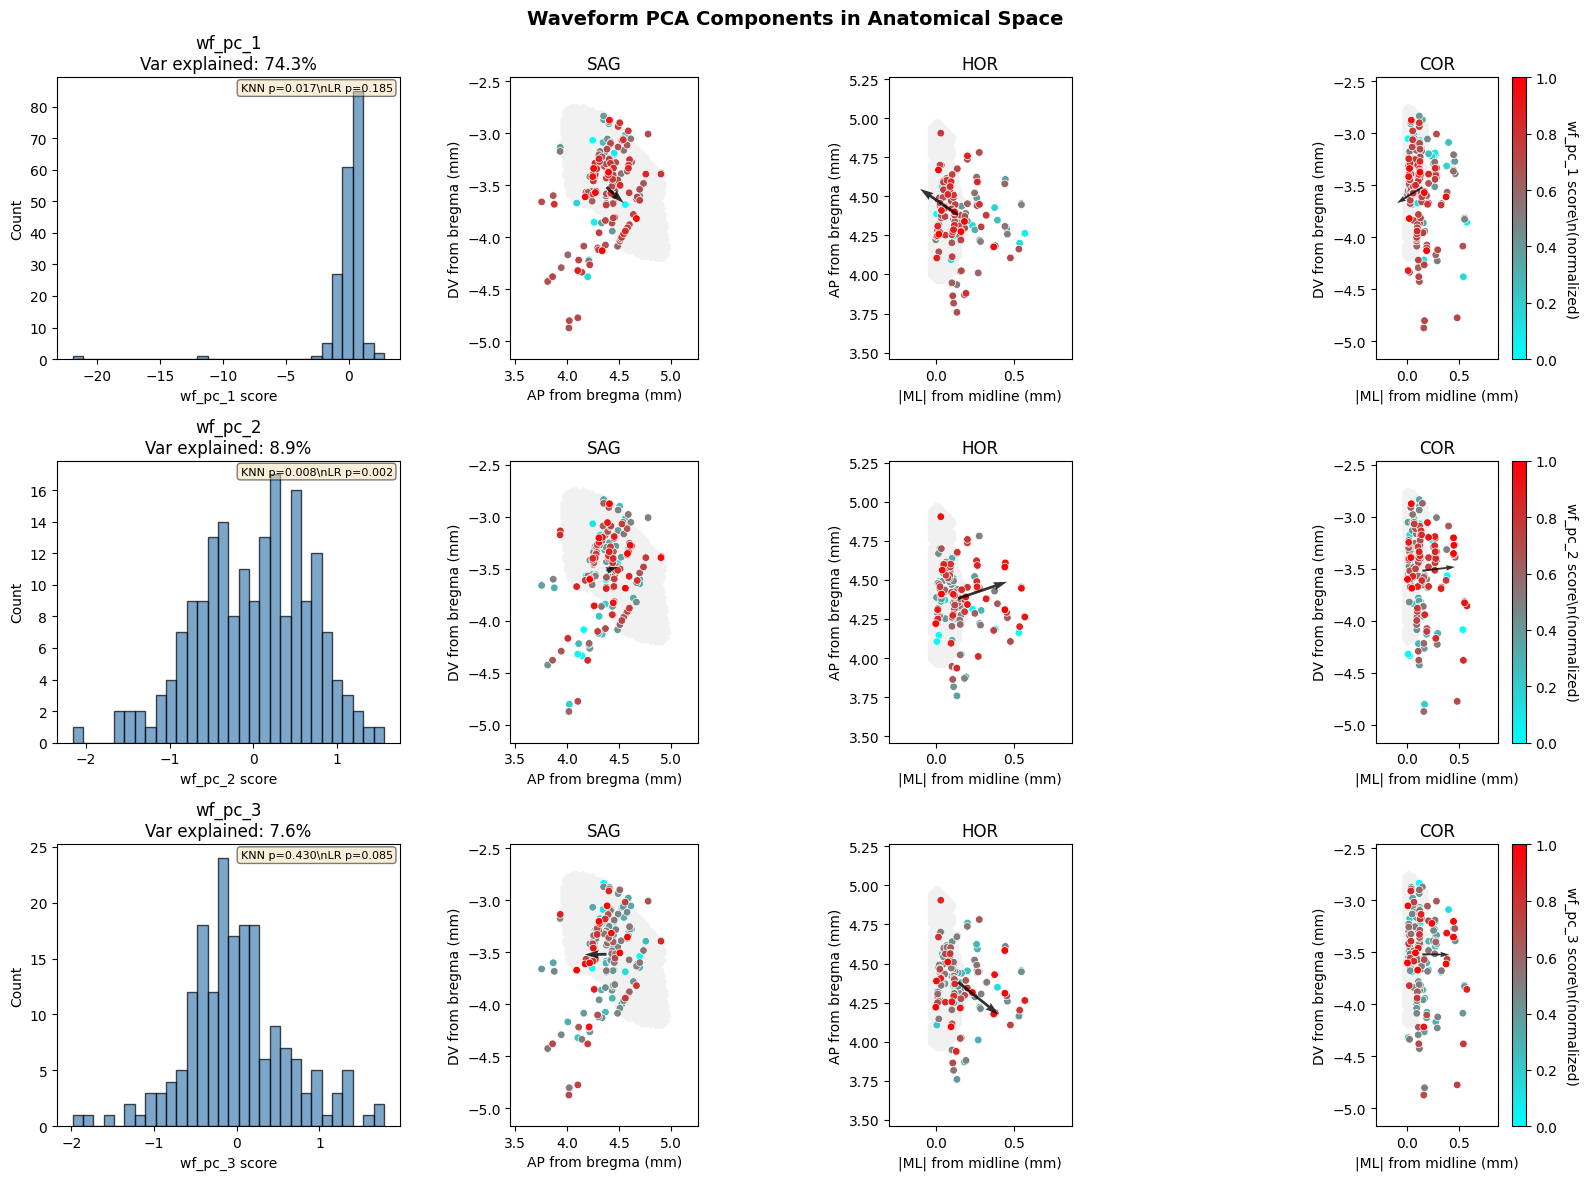

Plotted 3 PCA components across 188 units


In [26]:
# Plot first 3 PCA components in anatomical space
pca_components = ['wf_pc_1', 'wf_pc_2', 'wf_pc_3']
cmap_pca = LinearSegmentedColormap.from_list('blue_red', [(0, 'cyan'), (0.5, 'gray'), (1, 'red')])

fig, axes = plt.subplots(3, 4, figsize=(16, 12), squeeze=False)

for row, pc in enumerate(pca_components):
    pc_mask = np.isfinite(base_df[pc].to_numpy(dtype=float))
    df_pc = base_df.loc[pc_mask].copy()
    
    pc_values = df_pc[pc].to_numpy(dtype=float)
    ccfs_pc = np.stack(df_pc['ccf_plot'].to_numpy())
    wf_arrays_pc = df_pc.loc[df_pc['wf_norm_valid'], 'wf_nl'].to_numpy()
    
    # Histogram
    ax = axes[row, 0]
    ax.hist(pc_values, bins=30, color='steelblue', alpha=0.7, edgecolor='k')
    ax.set_title(f'{pc}\nVar explained: {waveform_pca.explained_variance_ratio_[row]:.1%}')
    ax.set_xlabel(f'{pc} score')
    ax.set_ylabel('Count')
    
    # Get spatial statistics if available
    if pc in spatial_dependence_results_pca:
        knn_p = spatial_dependence_results_pca[pc]['cv_predictability_knn']['p_value_permutation']
        lr_p = spatial_dependence_results_pca[pc]['linear_trend']['p_value_permutation_r2']
        ax.text(0.98, 0.98, f'KNN p={knn_p:.3f}\\nLR p={lr_p:.3f}', 
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # Get linear trend direction
        coef = np.asarray(spatial_dependence_results_pca[pc]['linear_trend']['coef_const_x_y_z'], dtype=float)
        arrow_vec = safe_unit_vectors(np.array([coef[1], coef[2], coef[3]]), axis=0)
        arrow_start = np.nanmean(ccfs_pc, axis=0)
    else:
        arrow_vec = None
        arrow_start = None
    
    # Normalize PC values for color mapping
    low, high = np.nanquantile(pc_values, [0.02, 0.98])
    pc_values_norm = np.clip(pc_values, low, high)
    pc_values_norm = (pc_values_norm - low) / (high - low) if (high - low) > 1e-12 else np.full_like(pc_values, 0.5)
    sort_ind = np.argsort(pc_values_norm)
    
    # Plot in 3 anatomical planes
    for col, (plane_name, plane_axes) in enumerate(planes.items(), start=1):
        ax = axes[row, col]
        pa = plane_axes
        
        # Mesh contours
        for contour in mesh_contours[plane_name]:
            ax.fill(contour[:, 0], contour[:, 1], color='lightgray', alpha=0.3, linewidth=0, zorder=0)
        
        # Scatter units colored by PC score
        sc = ax.scatter(
            ccfs_pc[sort_ind, pa[0]], ccfs_pc[sort_ind, pa[1]],
            c=pc_values_norm[sort_ind], cmap=cmap_pca, s=30,
            edgecolor='white', linewidth=0.5, zorder=2, vmin=0, vmax=1
        )
        
        # Arrow showing spatial gradient direction
        if arrow_vec is not None and np.isfinite(arrow_vec).all():
            ax.quiver(
                arrow_start[pa[0]], arrow_start[pa[1]],
                arrow_vec[pa[0]], arrow_vec[pa[1]],
                angles='xy', scale_units='xy', scale=3, 
                color='black', width=0.015, zorder=3, alpha=0.8
            )
        
        ax.set_xlabel(axis_names[pa[0]])
        ax.set_ylabel(axis_names[pa[1]])
        ax.set_title(f'{plane_name.upper()}')
        ax.set_aspect('equal')
        ax.set_xlim(plot_limits[plane_name]['xlim'])
        ax.set_ylim(plot_limits[plane_name]['ylim'])
        
        if col == 3:  # Add colorbar to last column
            cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label(f'{pc} score\\n(normalized)', rotation=270, labelpad=15)

plt.suptitle('Waveform PCA Components in Anatomical Space', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(target_folder, f'PCA_components_in_space_{criteria_name}.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(target_folder, f'PCA_components_in_space_{criteria_name}.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Plotted {len(pca_components)} PCA components across {len(df_pc)} units')

## 11. CCA: multivariate waveform features ↔ anatomy

CCA units: 185
Canonical correlations: [0.38940213 0.24806327 0.20304343]
CCF direction vectors (columns = components):
[[ 0.85028071 -0.23842036  0.46923176]
 [-0.17054264 -0.96822173 -0.18292593]
 [ 0.49793365  0.07551437 -0.8639211 ]]


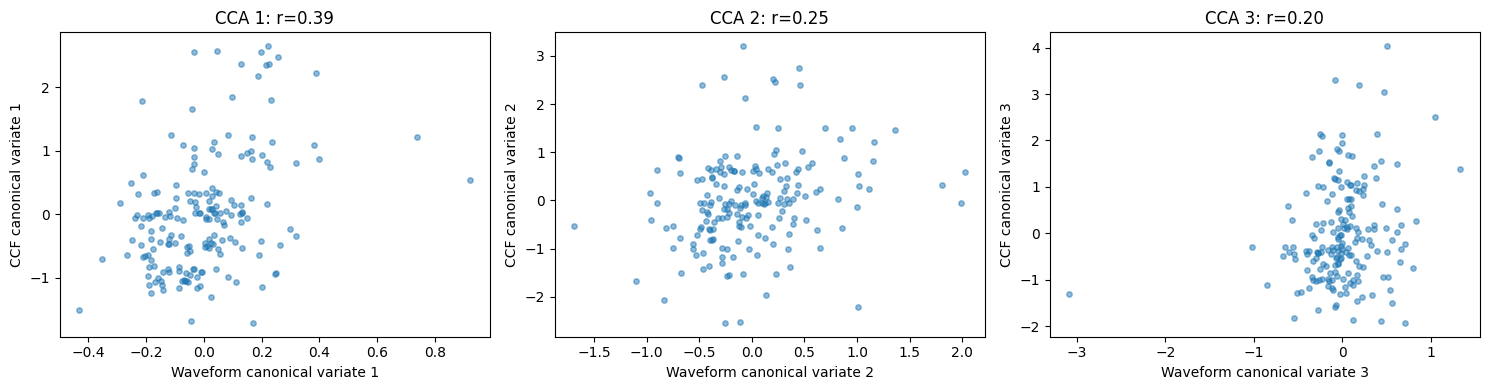

In [12]:
def prepare_cca(df, feature_cols, ranked_ccf=False):
    needed = feature_cols + CCF_COLS
    mask = finite_rows(df, needed)
    cca_df = df.loc[mask].copy().reset_index(drop=True)

    X = cca_df[feature_cols].to_numpy(dtype=float)
    Y = ccf_to_bregma_relative(cca_df)

    std = np.std(X, axis=0)
    bad = (~np.isfinite(std)) | (std <= 1e-12)
    if bad.any():
        raise ValueError(f'CCA zero/invalid variance features: {np.array(feature_cols)[bad].tolist()}')

    X = zscore(X, axis=0)
    if not np.isfinite(X).all() or not np.isfinite(Y).all():
        raise ValueError('Non-finite values remain in CCA inputs')

    if ranked_ccf:
        Y = np.column_stack([rankdata(Y[:, i], method='average') for i in range(Y.shape[1])])

    return cca_df, X, Y

cca_df, cca_X, cca_Y = prepare_cca(base_df, focus_features, ranked_ccf=False)
n_components = min(3, cca_X.shape[1], cca_Y.shape[1])
cca = CCA(n_components=n_components)
cca_wf_scores, cca_ccf_scores = cca.fit_transform(cca_X, cca_Y)
cca_corrs = np.array([
    np.corrcoef(cca_wf_scores[:, i], cca_ccf_scores[:, i])[0,1]
    for i in range(n_components)
])
cca_vecs = safe_unit_vectors(cca.y_weights_, axis=0)

print('CCA units:', len(cca_df))
print('Canonical correlations:', cca_corrs)
print('CCF direction vectors (columns = components):')
print(cca_vecs)

fig, axes = plt.subplots(1, n_components, figsize=(5*n_components, 4), squeeze=False)
for i in range(n_components):
    ax = axes[0, i]
    ax.scatter(cca_wf_scores[:,i], cca_ccf_scores[:,i], s=15, alpha=0.5)
    ax.set_xlabel(f'Waveform canonical variate {i+1}')
    ax.set_ylabel(f'CCF canonical variate {i+1}')
    ax.set_title(f'CCA {i+1}: r={cca_corrs[i]:.2f}')
plt.tight_layout()
plt.show()


## 11.5 CCA components visualized in anatomical space with direction vectors

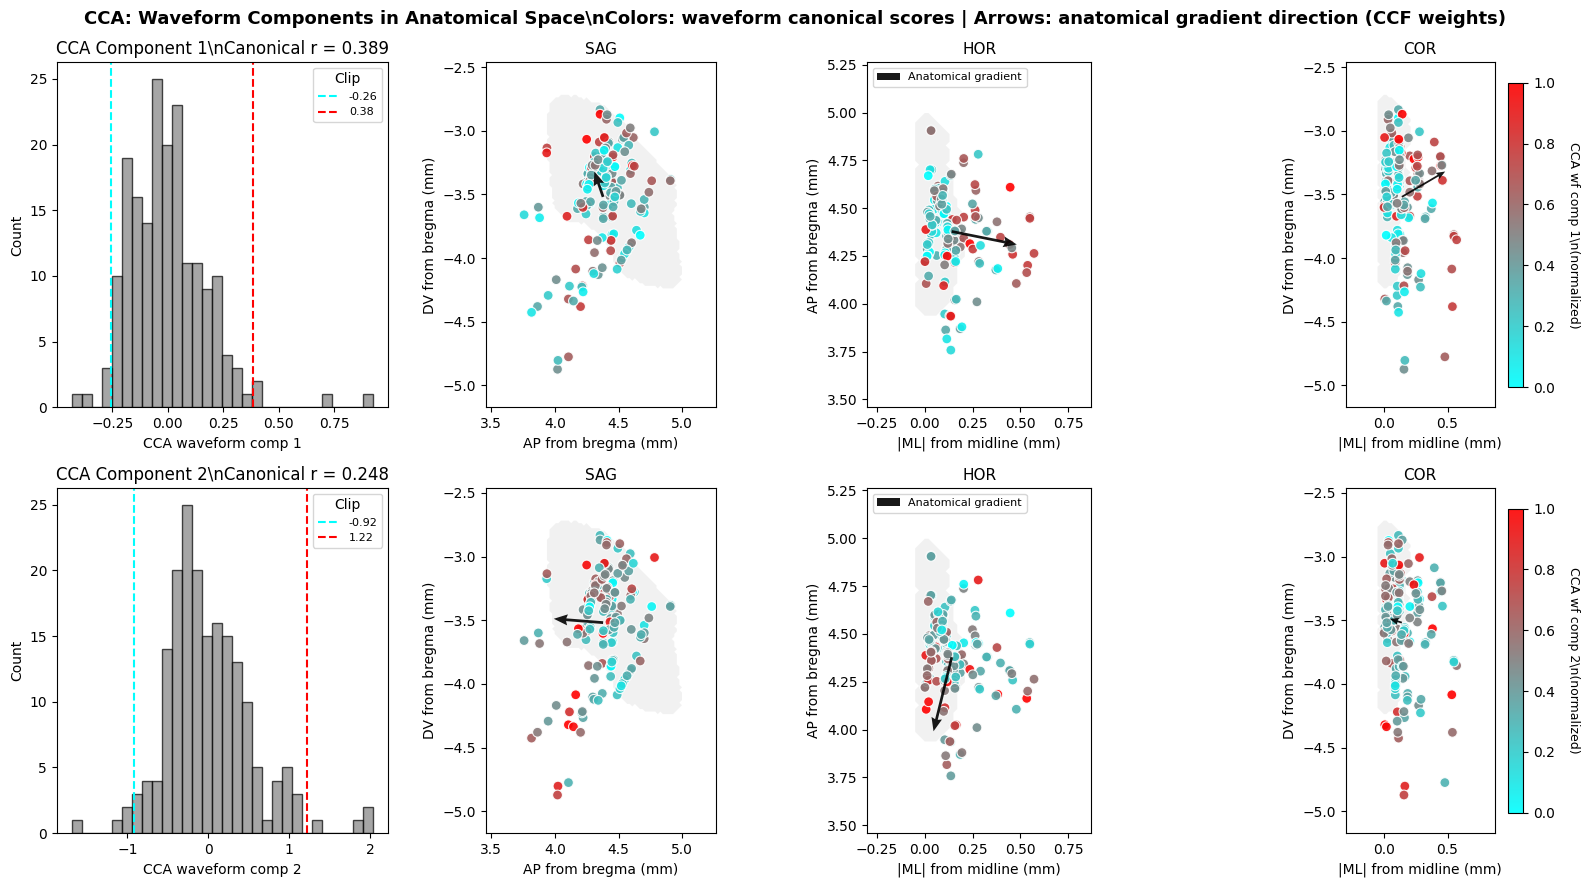

Plotted 2 CCA components:
  Component 1: r = 0.389, direction = [ 0.85028071 -0.17054264  0.49793365]
  Component 2: r = 0.248, direction = [-0.23842036 -0.96822173  0.07551437]


In [27]:
# Visualize CCA waveform components in anatomical space
# Show how waveform patterns (CCA waveform scores) map onto anatomy
# with vectors showing the anatomical gradient direction (CCA CCF weights)

custom_cmap = LinearSegmentedColormap.from_list(
    'cyan_gray_red', 
    [(0, (0, 1, 1)), (0.5, (0.5, 0.5, 0.5)), (1.0, (1, 0, 0))]
)

# Number of CCA components to visualize (typically 2)
n_cca_plot = min(2, n_components)

fig, axes = plt.subplots(n_cca_plot, 4, figsize=(16, 4.5 * n_cca_plot))
if n_cca_plot == 1:
    axes = axes[np.newaxis, :]  # Ensure 2D array

# Get CCF coordinates for CCA units
ccfs_cca = np.stack(cca_df['ccf_plot'].to_numpy())

for comp_idx in range(n_cca_plot):
    # Get CCA waveform scores (what we color by)
    cca_values = cca_wf_scores[:, comp_idx].copy()
    
    # Clip and normalize for visualization
    low, high = np.nanquantile(cca_values, [0.02, 0.98])
    cca_values_norm = np.clip(cca_values, low, high)
    cca_values_norm = (cca_values_norm - low) / (high - low) if (high - low) > 1e-12 else np.full_like(cca_values, 0.5)
    
    # Randomize plotting order within ties for cleaner visualization
    sort_ind = np.argsort(cca_values_norm)
    np.random.shuffle(sort_ind)
    
    # Histogram
    ax = axes[comp_idx, 0]
    ax.hist(cca_values, bins=30, color='gray', alpha=0.7, edgecolor='k')
    ax.axvline(low, linestyle='--', label=f'{low:.2f}', color=custom_cmap(0.01))
    ax.axvline(high, linestyle='--', label=f'{high:.2f}', color=custom_cmap(0.99))
    ax.set_xlabel(f'CCA waveform comp {comp_idx+1}')
    ax.set_ylabel('Count')
    ax.set_title(f'CCA Component {comp_idx+1}\\nCanonical r = {cca_corrs[comp_idx]:.3f}')
    ax.legend(title='Clip', fontsize=8, loc='upper right')
    
    # Get the anatomical direction vector (CCA CCF weights)
    ccf_direction = cca_vecs[:, comp_idx].copy()
    arrow_origin = np.nanmean(ccfs_cca, axis=0)
    
    # Plot in 3 anatomical planes
    for col, (plane_name, plane_axes) in enumerate(planes.items(), start=1):
        ax = axes[comp_idx, col]
        pa = plane_axes
        
        # Fill mesh contours
        for contour in mesh_contours[plane_name]:
            ax.fill(contour[:, 0], contour[:, 1], color='lightgray', alpha=0.3, linewidth=0, zorder=0)
        
        # Scatter units colored by CCA waveform score
        proj_ccf = ccfs_cca[:, pa]
        sc = ax.scatter(
            proj_ccf[sort_ind, 0], proj_ccf[sort_ind, 1],
            c=cca_values_norm[sort_ind], 
            cmap=custom_cmap,
            s=50, 
            edgecolor='white', 
            alpha=0.9, 
            linewidth=0.8,
            vmin=0, 
            vmax=1,
            zorder=2
        )
        
        # Plot CCA anatomical direction vector
        ax.quiver(
            arrow_origin[pa[0]], arrow_origin[pa[1]],
            ccf_direction[pa[0]], ccf_direction[pa[1]],
            angles='xy', 
            scale_units='xy', 
            scale=2.5,
            color='black', 
            width=0.012,
            headwidth=4,
            headlength=5,
            label=f'Anatomical gradient',
            zorder=3,
            alpha=0.9
        )
        
        ax.set_xlabel(axis_names[pa[0]], fontsize=10)
        ax.set_ylabel(axis_names[pa[1]], fontsize=10)
        ax.set_title(f'{plane_name.upper()}', fontsize=11)
        ax.set_aspect('equal')
        ax.set_xlim(plot_limits[plane_name]['xlim'])
        ax.set_ylim(plot_limits[plane_name]['ylim'])
        
        if plane_name == 'hor':
            ax.legend(loc='upper left', fontsize=8)
        
        if col == 3:  # Colorbar on last column
            cbar = fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label(f'CCA wf comp {comp_idx+1}\\n(normalized)', rotation=270, labelpad=18, fontsize=9)

plt.suptitle(
    'CCA: Waveform Components in Anatomical Space\\n' +
    'Colors: waveform canonical scores | Arrows: anatomical gradient direction (CCF weights)',
    fontsize=13, 
    fontweight='bold'
)
plt.tight_layout()
fig.savefig(os.path.join(target_folder, f'CCA_waveform_components_in_space_{criteria_name}.pdf'), dpi=300, bbox_inches='tight')
fig.savefig(os.path.join(target_folder, f'CCA_waveform_components_in_space_{criteria_name}.svg'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Plotted {n_cca_plot} CCA components:')
for i in range(n_cca_plot):
    print(f'  Component {i+1}: r = {cca_corrs[i]:.3f}, direction = {cca_vecs[:,i]}')

## 11.6 Mean waveforms binned by CCA components

Visualize how waveform shape changes along CCA components

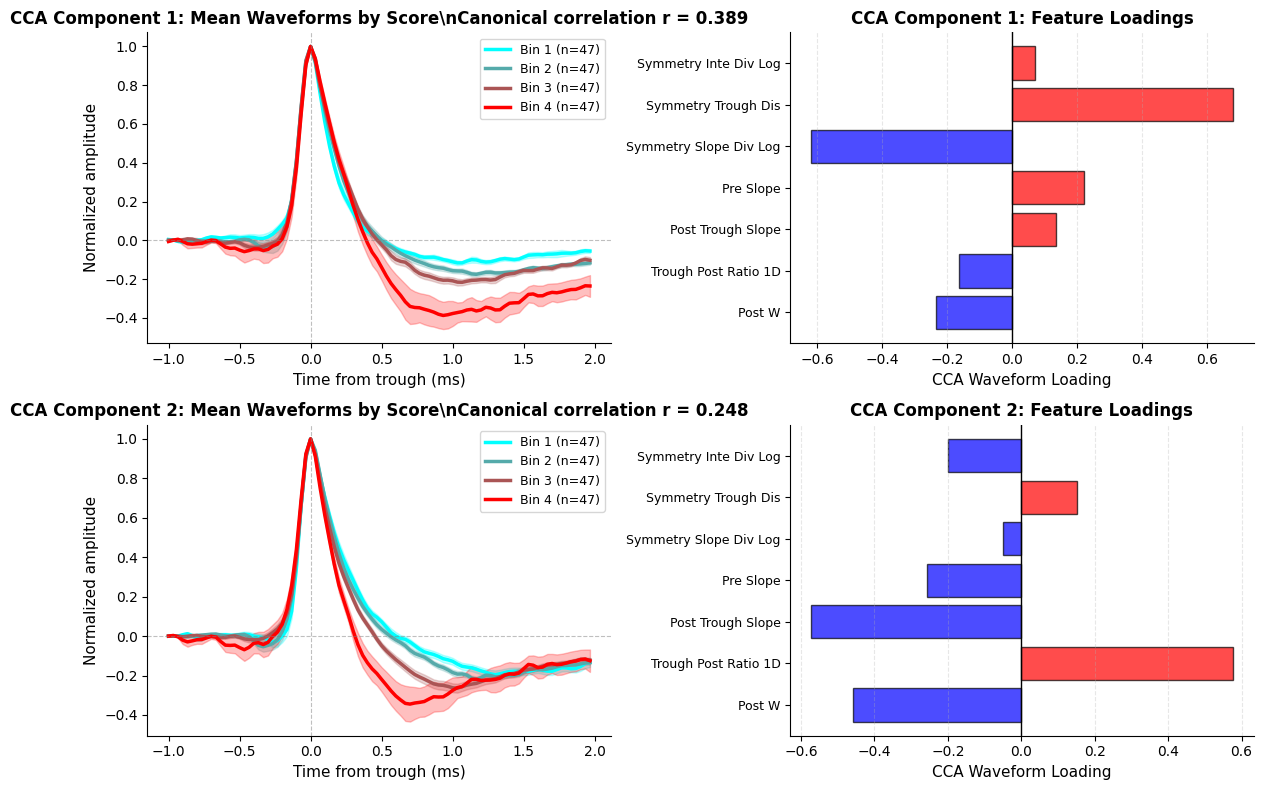

Binned waveforms for 2 CCA components
Waveforms per bin: 4 bins from 185 total units


In [28]:
# Plot mean waveforms binned by CCA component scores
# This shows what waveform features each CCA component captures

bin_num_cca = 4
wf_time = (np.arange(90) - 30) / 30  # ms, assuming 30kHz sampling

# Get waveforms for CCA units (only those with valid normalized waveforms)
cca_wf_mask = cca_df['wf_norm_valid'].to_numpy()
cca_waveforms = np.stack(cca_df.loc[cca_wf_mask, 'wf_nl'].to_numpy())

fig, axes = plt.subplots(n_cca_plot, 2, figsize=(12, 4 * n_cca_plot))
if n_cca_plot == 1:
    axes = axes[np.newaxis, :]

for comp_idx in range(n_cca_plot):
    # Get CCA scores for units with valid waveforms
    cca_scores_wf = cca_wf_scores[cca_wf_mask, comp_idx]
    
    # Bin waveforms by CCA score
    bin_edges = np.nanquantile(cca_scores_wf, np.linspace(0, 1, bin_num_cca + 1))
    
    # Plot waveforms in left panel
    ax_wf = axes[comp_idx, 0]
    for b in range(bin_num_cca):
        bin_mask = (cca_scores_wf >= bin_edges[b]) & (cca_scores_wf <= bin_edges[b + 1])
        if not bin_mask.any():
            continue
        
        wfs_bin = cca_waveforms[bin_mask]
        mean_wf = np.nanmean(wfs_bin, axis=0)
        n_eff = np.sum(np.isfinite(wfs_bin), axis=0)
        sem_wf = safe_divide(np.nanstd(wfs_bin, axis=0), np.sqrt(n_eff))
        
        color = custom_cmap(b / (bin_num_cca - 1))
        ax_wf.plot(wf_time, mean_wf, color=color, linewidth=2.5, 
                   label=f'Bin {b+1} (n={bin_mask.sum()})')
        ax_wf.fill_between(wf_time, mean_wf - sem_wf, mean_wf + sem_wf, 
                           color=color, alpha=0.25)
    
    ax_wf.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax_wf.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax_wf.set_xlabel('Time from trough (ms)', fontsize=11)
    ax_wf.set_ylabel('Normalized amplitude', fontsize=11)
    ax_wf.set_title(f'CCA Component {comp_idx+1}: Mean Waveforms by Score\\n' +
                    f'Canonical correlation r = {cca_corrs[comp_idx]:.3f}', 
                    fontsize=12, fontweight='bold')
    ax_wf.legend(loc='best', fontsize=9)
    ax_wf.spines['top'].set_visible(False)
    ax_wf.spines['right'].set_visible(False)
    
    # Plot waveform feature loadings in right panel
    ax_load = axes[comp_idx, 1]
    wf_loadings = cca.x_weights_[:, comp_idx]
    feature_names_plot = [f.replace('_', ' ').title() for f in focus_features]
    
    colors_load = ['red' if x > 0 else 'blue' for x in wf_loadings]
    bars = ax_load.barh(range(len(focus_features)), wf_loadings, color=colors_load, alpha=0.7, edgecolor='k')
    ax_load.set_yticks(range(len(focus_features)))
    ax_load.set_yticklabels(feature_names_plot, fontsize=9)
    ax_load.set_xlabel('CCA Waveform Loading', fontsize=11)
    ax_load.set_title(f'CCA Component {comp_idx+1}: Feature Loadings', 
                      fontsize=12, fontweight='bold')
    ax_load.axvline(0, color='black', linewidth=1)
    ax_load.spines['top'].set_visible(False)
    ax_load.spines['right'].set_visible(False)
    ax_load.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
fig.savefig(os.path.join(target_folder, f'CCA_waveforms_and_loadings_{criteria_name}.pdf'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Binned waveforms for {n_cca_plot} CCA components')
print(f'Waveforms per bin: {bin_num_cca} bins from {len(cca_waveforms)} total units')

## 12. Optional CCA bootstrap with safe normalization

This preserves the original notebook's voxel-stratified unit bootstrap idea, but skips failed/degenerate fits instead of propagating zero-norm vectors. **This is still a unit-level bootstrap, not yet a mouse/session hierarchical bootstrap.**

In [29]:
from collections import defaultdict

def bootstrap_cca_voxels(X, Y, n_boot=1000, n_bins_xyz=(3,3,4), seed=4):
    base = CCA(n_components=2).fit(X, Y)
    ref_xw = base.x_weights_.copy()
    ref_yw = safe_unit_vectors(base.y_weights_, axis=0)

    bins = [
        np.linspace(Y[:,i].min()-0.1, Y[:,i].max()+0.1, n_bins_xyz[i]+1)
        for i in range(3)
    ]
    digitized = [np.digitize(Y[:,i], bins[i])-1 for i in range(3)]
    voxel_map = defaultdict(list)
    for i in range(len(Y)):
        voxel_map[tuple(d[i] for d in digitized)].append(i)

    rng = np.random.default_rng(seed)
    boot_xw, boot_yw = [], []
    failed = 0

    for _ in range(n_boot):
        idx = []
        for members in voxel_map.values():
            idx.extend(rng.choice(members, size=len(members), replace=True))
        idx = np.asarray(idx)
        try:
            fit = CCA(n_components=2).fit(X[idx], Y[idx])
            xw = fit.x_weights_.copy()
            yw = safe_unit_vectors(fit.y_weights_, axis=0)
            if not np.isfinite(xw).all() or not np.isfinite(yw).all():
                failed += 1
                continue
            for comp in range(2):
                if np.dot(yw[:,comp], ref_yw[:,comp]) < 0:
                    yw[:,comp] *= -1
                    xw[:,comp] *= -1
            boot_xw.append(xw)
            boot_yw.append(yw)
        except Exception:
            failed += 1

    if not boot_xw:
        raise RuntimeError('All CCA bootstrap fits failed')

    return {
        'ref_xw': ref_xw,
        'ref_yw': ref_yw,
        'boot_xw': np.stack(boot_xw),
        'boot_yw': np.stack(boot_yw),
        'failed': failed,
    }

# Example (can be slow):
# cca_boot = bootstrap_cca_voxels(cca_X, cca_Y, n_boot=1000)
# print('Successful:', len(cca_boot['boot_xw']), 'Failed:', cca_boot['failed'])


## 12.5 Run CCA Bootstrap and Visualize Confidence Intervals

In [30]:
# Run CCA bootstrap (WARNING: Can take 2-5 minutes for 1000 iterations)
print('Running CCA bootstrap (this may take a few minutes)...')
import time
start_time = time.time()

cca_boot = bootstrap_cca_voxels(cca_X, cca_Y, n_boot=1000, n_bins_xyz=(3,3,4), seed=RANDOM_SEED)

elapsed = time.time() - start_time
print(f'Bootstrap completed in {elapsed:.1f} seconds')
print(f'Successful fits: {len(cca_boot["boot_xw"])}')
print(f'Failed fits: {cca_boot["failed"]}')
print(f'Success rate: {len(cca_boot["boot_xw"])/(len(cca_boot["boot_xw"])+cca_boot["failed"])*100:.1f}%')

# Save bootstrap results
boot_file = os.path.join(target_folder, f'CCA_bootstrap_results_{criteria_name}.pkl')
with open(boot_file, 'wb') as f:
    pickle.dump(cca_boot, f)
print(f'Saved to: {boot_file}')

Running CCA bootstrap (this may take a few minutes)...
Bootstrap completed in 2.3 seconds
Successful fits: 1000
Failed fits: 0
Success rate: 100.0%
Saved to: /root/capsule/scratch/results/manuscript/figures/F_waveform_space_DRN_v2/CCA_bootstrap_results_waveform_low_DRN.pkl


### Visualize Bootstrap Results

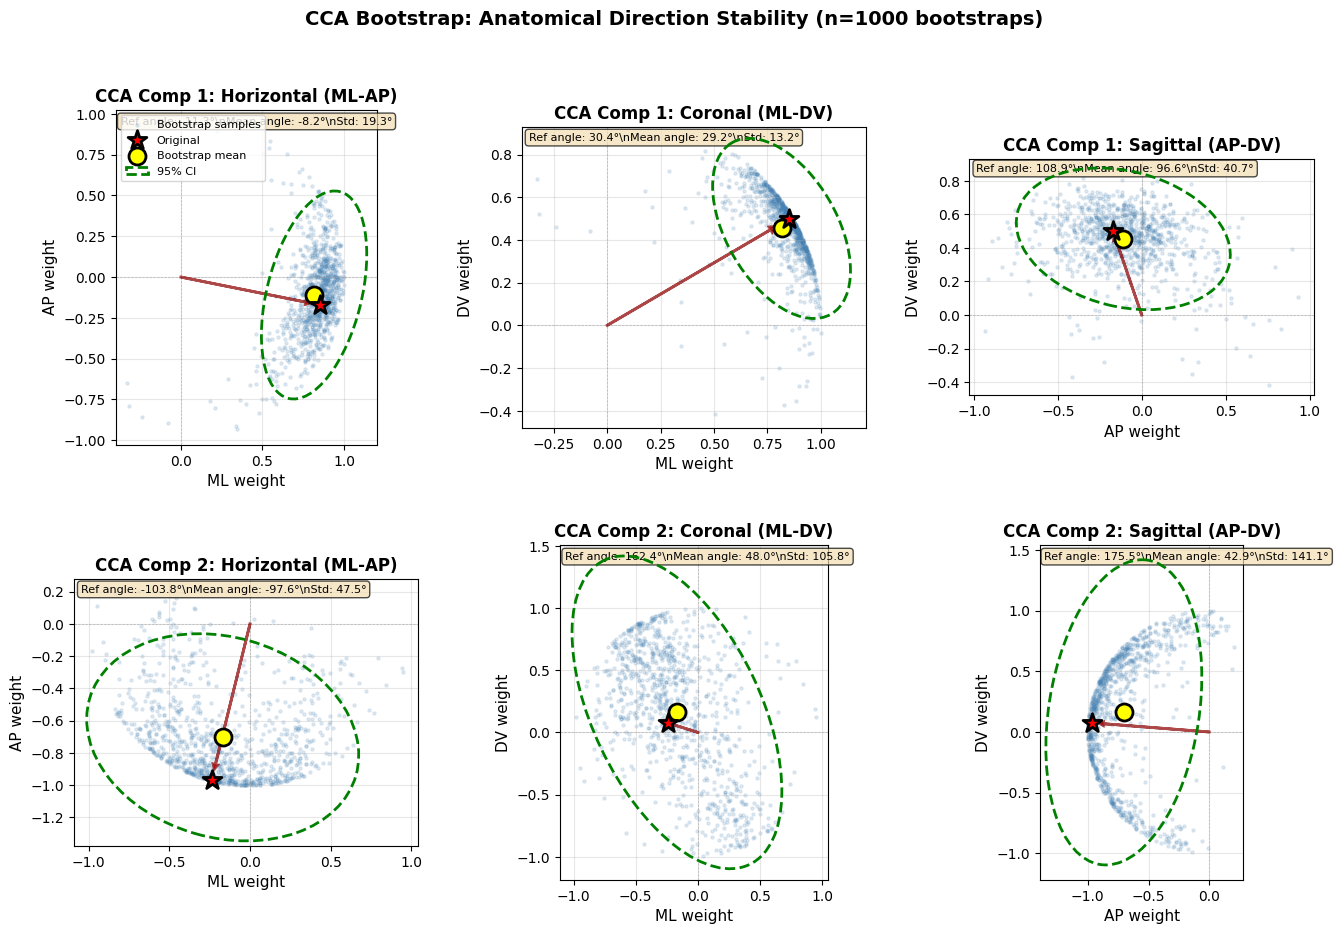

Bootstrap Direction Stability Summary:
\nComponent 1:
  ML: ref=+0.850, mean=+0.817, std=0.132, 95%CI=[+0.524, +0.970]
  AP: ref=-0.171, mean=-0.110, std=0.260, 95%CI=[-0.625, +0.450]
  DV: ref=+0.498, mean=+0.454, std=0.172, 95%CI=[+0.030, +0.717]
\nComponent 2:
  ML: ref=-0.238, mean=-0.169, std=0.344, 95%CI=[-0.742, +0.528]
  AP: ref=-0.968, mean=-0.703, std=0.262, 95%CI=[-0.992, -0.025]
  DV: ref=+0.076, mean=+0.162, std=0.513, 95%CI=[-0.865, +0.911]


In [31]:
# Extract bootstrap results
boot_yw = cca_boot['boot_yw']  # Shape: (n_boot, 3 CCF dims, 2 components)
boot_xw = cca_boot['boot_xw']  # Shape: (n_boot, 7 features, 2 components)
ref_yw = cca_boot['ref_yw']    # Reference (original) CCF weights
ref_xw = cca_boot['ref_xw']    # Reference (original) feature weights

n_boot_success = boot_yw.shape[0]

# ========================================
# Figure 1: Anatomical Direction Vectors with Confidence
# ========================================
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

axis_pairs = [(ml, ap), (ml, dv), (ap, dv)]
axis_names_short = ['ML', 'AP', 'DV']
plane_names = ['Horizontal (ML-AP)', 'Coronal (ML-DV)', 'Sagittal (AP-DV)']

for comp_idx in range(2):  # CCA components 1 and 2
    for plane_idx, (ax_i, ax_j) in enumerate(axis_pairs):
        ax = fig.add_subplot(gs[comp_idx, plane_idx])
        
        # Bootstrap distribution of direction vectors
        boot_dirs = boot_yw[:, [ax_i, ax_j], comp_idx]
        
        # Plot bootstrap samples as light scatter
        ax.scatter(boot_dirs[:, 0], boot_dirs[:, 1], 
                  s=5, alpha=0.15, color='steelblue', label='Bootstrap samples')
        
        # Reference (original) direction
        ref_dir = ref_yw[[ax_i, ax_j], comp_idx]
        ax.scatter(ref_dir[0], ref_dir[1], 
                  s=200, marker='*', color='red', 
                  edgecolor='black', linewidth=2, 
                  label='Original', zorder=10)
        
        # Mean of bootstrap
        boot_mean = np.mean(boot_dirs, axis=0)
        ax.scatter(boot_mean[0], boot_mean[1], 
                  s=150, marker='o', color='yellow', 
                  edgecolor='black', linewidth=2, 
                  label='Bootstrap mean', zorder=9)
        
        # 95% confidence ellipse
        from matplotlib.patches import Ellipse
        from scipy import stats
        
        # Compute covariance and eigenvalues for ellipse
        cov = np.cov(boot_dirs.T)
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        
        # Chi-square 95% confidence interval
        chi2_val = stats.chi2.ppf(0.95, df=2)
        width, height = 2 * np.sqrt(chi2_val * eigenvalues)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        
        ellipse = Ellipse(xy=boot_mean, width=width, height=height, 
                         angle=angle, facecolor='none', 
                         edgecolor='green', linewidth=2, linestyle='--',
                         label='95% CI', zorder=8)
        ax.add_patch(ellipse)
        
        # Arrow from origin to reference
        ax.arrow(0, 0, ref_dir[0]*0.9, ref_dir[1]*0.9, 
                head_width=0.03, head_length=0.03, 
                fc='red', ec='darkred', linewidth=2, 
                alpha=0.7, zorder=7)
        
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.axvline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
        
        ax.set_xlabel(f'{axis_names_short[ax_i]} weight', fontsize=11)
        ax.set_ylabel(f'{axis_names_short[ax_j]} weight', fontsize=11)
        ax.set_title(f'CCA Comp {comp_idx+1}: {plane_names[plane_idx]}', 
                    fontsize=12, fontweight='bold')
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        
        if comp_idx == 0 and plane_idx == 0:
            ax.legend(loc='best', fontsize=8)
        
        # Compute angular stability
        angles = np.arctan2(boot_dirs[:, 1], boot_dirs[:, 0])
        angles_deg = np.degrees(angles)
        ref_angle = np.degrees(np.arctan2(ref_dir[1], ref_dir[0]))
        
        # Circular statistics for angle
        angle_std = np.std(angles_deg)
        
        ax.text(0.02, 0.98, 
               f'Ref angle: {ref_angle:.1f}°\\n' +
               f'Mean angle: {np.mean(angles_deg):.1f}°\\n' +
               f'Std: {angle_std:.1f}°',
               transform=ax.transAxes, 
               fontsize=8,
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.suptitle(f'CCA Bootstrap: Anatomical Direction Stability (n={n_boot_success} bootstraps)', 
            fontsize=14, fontweight='bold')
fig.savefig(os.path.join(target_folder, f'CCA_bootstrap_direction_stability_{criteria_name}.pdf'), 
           dpi=300, bbox_inches='tight')
plt.show()

print('Bootstrap Direction Stability Summary:')
print('='*60)
for comp_idx in range(2):
    print(f'\\nComponent {comp_idx+1}:')
    for dim, name in enumerate(['ML', 'AP', 'DV']):
        boot_vals = boot_yw[:, dim, comp_idx]
        ref_val = ref_yw[dim, comp_idx]
        mean_val = np.mean(boot_vals)
        std_val = np.std(boot_vals)
        ci_low, ci_high = np.percentile(boot_vals, [2.5, 97.5])
        
        print(f'  {name}: ref={ref_val:+.3f}, mean={mean_val:+.3f}, std={std_val:.3f}, ' +
              f'95%CI=[{ci_low:+.3f}, {ci_high:+.3f}]')

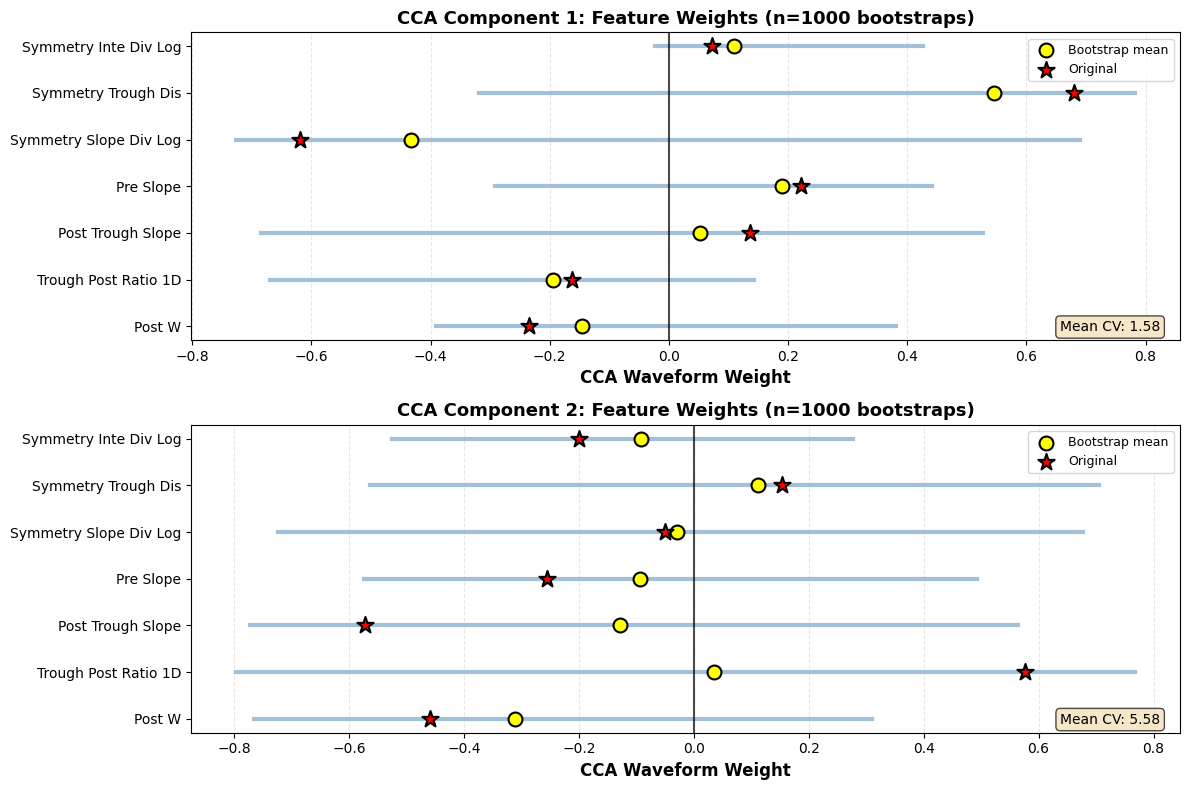

\nBootstrap Feature Weight Summary:
\nComponent 1:
Feature                          Original       Mean      Std               95% CI
--------------------------------------------------------------------------------
post_w                             -0.234     -0.146    0.180 [ -0.390,   0.381] *
trough_post_ratio_1D               -0.162     -0.194    0.205 [ -0.670,   0.143] *
post_trough_slope                   0.136      0.052    0.284 [ -0.684,   0.527] *
pre_slope                           0.222      0.189    0.171 [ -0.291,   0.441] *
symmetry_slope_div_log             -0.619     -0.433    0.371 [ -0.727,   0.689] *
symmetry_trough_dis                 0.680      0.546    0.265 [ -0.319,   0.782] *
symmetry_inte_div_log               0.072      0.109    0.113 [ -0.023,   0.426] *
\n* = 95% CI includes zero (weight not significantly different from 0)
\nComponent 2:
Feature                          Original       Mean      Std               95% CI
-----------------------------------

In [32]:
# ========================================
# Figure 2: Waveform Feature Weights with Confidence Intervals
# ========================================
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for comp_idx in range(2):
    ax = axes[comp_idx]
    
    # Get bootstrap distributions for each feature
    feature_names_plot = [f.replace('_', ' ').title() for f in focus_features]
    
    for feat_idx in range(len(focus_features)):
        boot_weights = boot_xw[:, feat_idx, comp_idx]
        ref_weight = ref_xw[feat_idx, comp_idx]
        
        # Compute statistics
        mean_weight = np.mean(boot_weights)
        ci_low, ci_high = np.percentile(boot_weights, [2.5, 97.5])
        
        # Plot
        y_pos = feat_idx
        
        # Confidence interval as horizontal line
        ax.plot([ci_low, ci_high], [y_pos, y_pos], 
               color='steelblue', linewidth=3, alpha=0.5, zorder=1)
        
        # Bootstrap mean as circle
        ax.scatter(mean_weight, y_pos, 
                  s=100, color='yellow', edgecolor='k', linewidth=1.5, 
                  zorder=3, label='Bootstrap mean' if feat_idx == 0 else '')
        
        # Reference (original) as star
        ax.scatter(ref_weight, y_pos, 
                  s=150, marker='*', color='red', edgecolor='k', linewidth=1.5, 
                  zorder=4, label='Original' if feat_idx == 0 else '')
    
    ax.axvline(0, color='black', linewidth=1.5, linestyle='-', alpha=0.7)
    ax.set_yticks(range(len(focus_features)))
    ax.set_yticklabels(feature_names_plot, fontsize=10)
    ax.set_xlabel('CCA Waveform Weight', fontsize=12, fontweight='bold')
    ax.set_title(f'CCA Component {comp_idx+1}: Feature Weights (n={n_boot_success} bootstraps)', 
                fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=9)
    
    # Add text with stability metric
    # Compute coefficient of variation for each feature
    cv_mean = np.mean([np.std(boot_xw[:, i, comp_idx])/np.abs(np.mean(boot_xw[:, i, comp_idx])) 
                       for i in range(len(focus_features)) 
                       if np.abs(np.mean(boot_xw[:, i, comp_idx])) > 0.01])
    
    ax.text(0.98, 0.02, f'Mean CV: {cv_mean:.2f}', 
           transform=ax.transAxes, fontsize=10,
           ha='right', va='bottom',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
fig.savefig(os.path.join(target_folder, f'CCA_bootstrap_feature_weights_{criteria_name}.pdf'), 
           dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print('\\nBootstrap Feature Weight Summary:')
print('='*80)
for comp_idx in range(2):
    print(f'\\nComponent {comp_idx+1}:')
    print(f'{"Feature":<30} {"Original":>10} {"Mean":>10} {"Std":>8} {"95% CI":>20}')
    print('-'*80)
    for feat_idx, feat_name in enumerate(focus_features):
        boot_weights = boot_xw[:, feat_idx, comp_idx]
        ref_weight = ref_xw[feat_idx, comp_idx]
        mean_weight = np.mean(boot_weights)
        std_weight = np.std(boot_weights)
        ci_low, ci_high = np.percentile(boot_weights, [2.5, 97.5])
        
        # Check if CI includes zero (not significant)
        includes_zero = (ci_low <= 0 <= ci_high)
        marker = ' ' if not includes_zero else '*'
        
        print(f'{feat_name:<30} {ref_weight:>10.3f} {mean_weight:>10.3f} {std_weight:>8.3f} ' +
              f'[{ci_low:>7.3f}, {ci_high:>7.3f}] {marker}')
    
    print('\\n* = 95% CI includes zero (weight not significantly different from 0)')

### Interpreting Bootstrap Results

**Key Questions Answered:**

1. **Is the anatomical gradient stable?**
   - Look at the confidence ellipses in the direction plots
   - **Narrow ellipse** = consistent direction across bootstraps = **reliable gradient**
   - **Wide ellipse** = variable direction = **unstable/weak gradient**

2. **Which anatomical axis matters most?**
   - Check which dimension (ML/AP/DV) has:
     - Large weight magnitude
     - **95% CI that excludes zero**
   - Example: If AP weight = -0.88, CI = [-0.95, -0.81] → **Rostral-caudal axis is significant**

3. **Which waveform features drive the effect?**
   - Features with **95% CI excluding zero** are significant contributors
   - Sign indicates direction: positive = feature increases caudally

4. **How confident should I be?**
   - **Angular std < 15°**: Very stable direction
   - **Angular std 15-30°**: Moderately stable
   - **Angular std > 30°**: Unstable, interpret cautiously

---

**IMPORTANT CAVEAT:**

This bootstrap resamples **units** within spatial voxels. It does NOT account for:
- **Hierarchical structure**: Units nest within sessions, sessions nest within mice
- **Non-independence**: Units from the same probe are correlated

**For publication-quality inference:**
- Consider hierarchical bootstrap (mouse → session → unit)
- Or use mixed-effects models with random effects for mouse/session
- Current bootstrap underestimates uncertainty

**What it IS good for:**
- Checking if results are sensitive to outlier units
- Verifying sign stability (does the gradient flip in bootstraps?)
- Exploratory assessment before more rigorous inference

## 13. Analysis audit / final sanity checks

In [14]:
print('=== DRN WAVEFORM ANALYSIS AUDIT ===')
print('QC-tagged units:             ', len(combined_tagged_units_filtered))
print('Waveform-feature units:      ', len(wf_features))
print('Canonical merged units:      ', len(analysis_df))
print('Base spatial units:          ', len(base_df))
print('Valid normalized waveforms:  ', int(base_df.wf_norm_valid.sum()))
print('Unique sessions:             ', base_df.session.nunique())
print('CCA units:                    ', len(cca_df))

print()
print('Focus-feature valid N:')
for f in focus_features:
    print(f'{f:28s} {np.isfinite(base_df[f].to_numpy(dtype=float)).sum():4d}')

# Fail loudly if infinities have leaked back into scalar numeric columns.
scalar_numeric = base_df.select_dtypes(include=np.number)
assert not np.isinf(scalar_numeric.to_numpy()).any(), 'Infinity found in base_df numeric columns'
print()
print('No +/-inf values in scalar analysis columns.')


=== DRN WAVEFORM ANALYSIS AUDIT ===
QC-tagged units:              207
Waveform-feature units:       189
Canonical merged units:       189
Base spatial units:           189
Valid normalized waveforms:   188
Unique sessions:              37
CCA units:                     185

Focus-feature valid N:
post_w                        185
trough_post_ratio_1D          185
post_trough_slope             185
pre_slope                     185
symmetry_slope_div_log        185
symmetry_trough_dis           185
symmetry_inte_div_log         185

No +/-inf values in scalar analysis columns.


## Notes for inference

- The KNN/LR permutation tests here retain the original **unit-level** permutation logic. Units from the same session/probe are not independent biological replicates.
- The voxel CCA bootstrap likewise resamples units within spatial voxels. Treat it as exploratory until the resampling hierarchy is upgraded to mouse → session/probe → unit.
- `|ML|` is mirrored across the midline. An ML effect therefore means **medial ↔ lateral**, not left ↔ right.
- The DR mesh is a reference overlay; units outside the mesh remain part of the analysis unless you explicitly add an anatomical inclusion criterion.
